# 04 - Filtros digitales FIR/IIR

Acá cierro la parte de filtros digitales. La idea es elegir una banda de interés mirando la PSD, diseñar un filtro FIR y un IIR, comparar sus respuestas en frecuencia y ver qué cambia en la señal y en la PSD después de filtrar.

No lo uso como detector de drones. Lo uso como una herramienta de Análisis y Procesamiento de Señales para estudiar qué pasa si selecciono una zona del espectro.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import signal

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from aps_drone_rf.config import DATA_DIR, DRONERF_TIME_FS_HZ, FIGURES_DIR, TABLES_DIR, ensure_project_dirs
from aps_drone_rf.estilo import COLOR_SERIE, aplicar_estilo_matplotlib, color_clase, nombre_clase
from aps_drone_rf.filters import (
    is_iir_stable,
    response_on_unit_circle,
    transfer_function_expression,
    zeros_and_poles,
)
from aps_drone_rf.io import discover_signal_manifest, load_record
from aps_drone_rf.plots import save_figure
from aps_drone_rf.preprocessing import normalize_signal
from aps_drone_rf.synthetic import add_awgn, pure_tone, white_noise

ensure_project_dirs()
aplicar_estilo_matplotlib()

SEED = 42
plt.rcParams["figure.figsize"] = (8, 3)
plt.rcParams["axes.grid"] = True


## Cargo las señales

Trabajo con un ejemplo de fondo y uno con actividad de dron. Si DroneRF no está disponible, el notebook usa señales sintéticas para que el flujo siga funcionando.


In [2]:
def cargar_par_fondo_dron(n_muestras_dronerf=100_000):
    manifest = discover_signal_manifest(DATA_DIR)

    if not manifest.empty and "label" in manifest.columns:
        manifest = manifest[manifest["label"].isin(["fondo", "dron"])].copy()

    if not manifest.empty and {"fondo", "dron"}.issubset(set(manifest["label"])):
        tabla = manifest.copy()

        if "dronerf_part" in tabla.columns:
            parte_l = tabla[tabla["dronerf_part"].str.upper() == "L"]
            if {"fondo", "dron"}.issubset(set(parte_l["label"])):
                tabla = parte_l

        fila_fondo = tabla[tabla["label"] == "fondo"].iloc[0]
        fila_dron = tabla[tabla["label"] == "dron"].iloc[0]

        rec_fondo = load_record(fila_fondo, fs_hz=DRONERF_TIME_FS_HZ, normalize=True)
        rec_dron = load_record(fila_dron, fs_hz=DRONERF_TIME_FS_HZ, normalize=True)

        n = min(n_muestras_dronerf, len(rec_fondo.signal), len(rec_dron.signal))

        return {
            "fuente": "DroneRF local",
            "fs": DRONERF_TIME_FS_HZ,
            "x_fondo": np.real(rec_fondo.signal[:n]),
            "x_dron": np.real(rec_dron.signal[:n]),
            "grupo_fondo": rec_fondo.group_id,
            "grupo_dron": rec_dron.group_id,
        }

    fs = 2_000.0
    n = int(fs)
    ruido_fondo = white_noise(n, sigma=0.5, seed=SEED)
    _, tono = pure_tone(180.0, fs, 1.0, amplitude=0.9)

    return {
        "fuente": "señales sintéticas",
        "fs": fs,
        "x_fondo": normalize_signal(ruido_fondo),
        "x_dron": normalize_signal(add_awgn(tono, snr_db=8.0, seed=SEED + 1)),
        "grupo_fondo": "sintetico_fondo",
        "grupo_dron": "sintetico_dron",
    }


datos = cargar_par_fondo_dron()
fuente = datos["fuente"]
fs = datos["fs"]
x_fondo = datos["x_fondo"]
x_dron = datos["x_dron"]

N = min(len(x_fondo), len(x_dron))
x_fondo = x_fondo[:N]
x_dron = x_dron[:N]

ts = 1 / fs
df = fs / N
tt = np.arange(N) * ts
ff = np.fft.rfftfreq(N, d=ts)

if fuente == "DroneRF local":
    tt_grafico = tt * 1e6
    unidad_tiempo = "us"
    escala_f = 1e6
    unidad_f = "MHz"
else:
    tt_grafico = tt
    unidad_tiempo = "s"
    escala_f = 1.0
    unidad_f = "Hz"

print("Fuente:", fuente)
print(f"fs = {fs:.1f} Hz")
print(f"N = {N}")
print(f"df = {df:.3f} Hz")
print("grupo fondo =", datos["grupo_fondo"])
print("grupo dron =", datos["grupo_dron"])


Fuente: DroneRF local
fs = 40000000.0 Hz
N = 100000
df = 400.000 Hz
grupo fondo = dronerf_00000_0
grupo dron = dronerf_10000_0


## Elijo una banda mirando la PSD

Primero calculo Welch para fondo y dron. Después busco una componente dominante en la señal con dron y armo una banda alrededor. Esta banda es una decisión de análisis para probar filtros, no una regla universal.


Frecuencia de referencia: 10.010 MHz
Banda elegida: 9.260 a 10.760 MHz


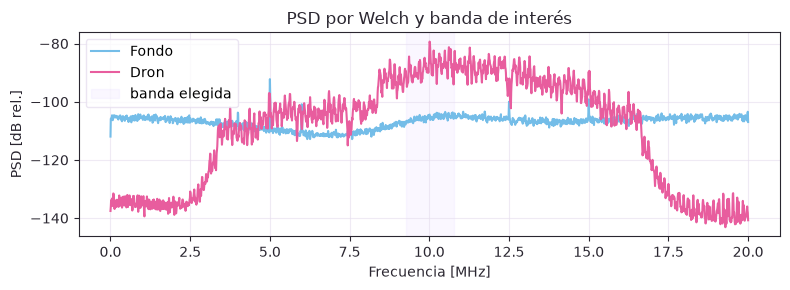

In [3]:
nperseg = 4096 if fuente == "DroneRF local" else 256
noverlap = nperseg // 2

f_w_fondo, p_w_fondo = signal.welch(x_fondo, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
f_w_dron, p_w_dron = signal.welch(x_dron, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")

mascara = (f_w_dron > 0.02 * (fs / 2)) & (f_w_dron < 0.92 * (fs / 2))
f_dom = f_w_dron[mascara][np.argmax(p_w_dron[mascara])] if np.any(mascara) else 0.10 * fs

ancho_banda = 1.5e6 if fuente == "DroneRF local" else 120.0
f1 = max(1.0, f_dom - ancho_banda / 2)
f2 = min(0.95 * fs / 2, f_dom + ancho_banda / 2)
banda_paso = (f1, f2)
centro_banda = 0.5 * (f1 + f2)

print(f"Frecuencia de referencia: {f_dom / escala_f:.3f} {unidad_f}")
print(f"Banda elegida: {f1 / escala_f:.3f} a {f2 / escala_f:.3f} {unidad_f}")

fig, ax = plt.subplots()
ax.plot(f_w_fondo / escala_f, 10 * np.log10(np.maximum(p_w_fondo, 1e-20)), label=nombre_clase("fondo"), color=color_clase("fondo"))
ax.plot(f_w_dron / escala_f, 10 * np.log10(np.maximum(p_w_dron, 1e-20)), label=nombre_clase("dron"), color=color_clase("dron"))
ax.axvspan(f1 / escala_f, f2 / escala_f, alpha=0.12, color="#D7C2FF", label="banda elegida")
ax.set_title("PSD por Welch y banda de interés")
ax.set_xlabel(f"Frecuencia [{unidad_f}]")
ax.set_ylabel("PSD [dB rel.]")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb04_psd_banda_interes.png")
plt.show()


## Diseño de filtros

Diseño dos filtros pasa banda sobre la misma banda: un FIR por ventana de Hamming y un IIR Butterworth. Para el IIR reviso estabilidad mirando que los polos queden dentro del círculo unitario.


IIR estable: True
Máximo módulo de polos: 0.9562


C:\Users\msere\Repositorios\APS\src\aps_drone_rf\plots.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


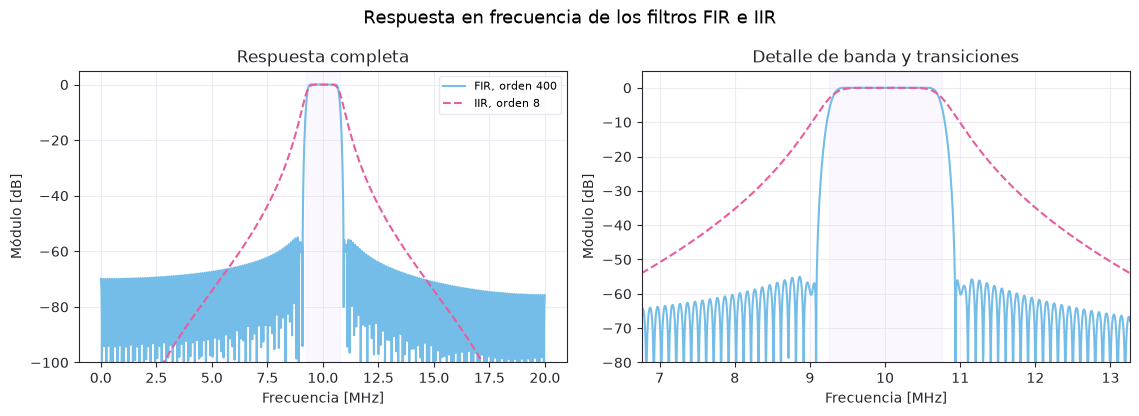

In [4]:
numtaps_fir = 401 if fuente == "DroneRF local" else 101
orden_iir_base = 4

b_fir = signal.firwin(
    numtaps=numtaps_fir,
    cutoff=banda_paso,
    fs=fs,
    pass_zero=False,
    window="hamming",
)
a_fir = np.array([1.0])

b_iir, a_iir = signal.iirfilter(
    orden_iir_base, banda_paso, fs=fs, btype="bandpass", ftype="butter", output="ba"
)
sos_iir = signal.iirfilter(
    orden_iir_base, banda_paso, fs=fs, btype="bandpass", ftype="butter", output="sos"
)

f_fir, h_fir = signal.freqz(b_fir, a_fir, worN=4096, fs=fs)
f_iir, h_iir = signal.sosfreqz(sos_iir, worN=4096, fs=fs)
db_fir = 20 * np.log10(np.maximum(np.abs(h_fir), 1e-12))
db_iir = 20 * np.log10(np.maximum(np.abs(h_iir), 1e-12))

ceros_iir, polos_iir = zeros_and_poles(b_iir, a_iir)
radio_max_polo = np.max(np.abs(polos_iir))
estable_iir = is_iir_stable(a_iir)

print("IIR estable:", estable_iir)
print(f"Máximo módulo de polos: {radio_max_polo:.4f}")

fig, ejes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
for eje in ejes:
    eje.plot(f_fir / escala_f, db_fir, label="FIR, orden 400", color=COLOR_SERIE["fir"])
    eje.plot(f_iir / escala_f, db_iir, "--", label="IIR, orden 8", color=COLOR_SERIE["iir"])
    eje.axvspan(f1 / escala_f, f2 / escala_f, alpha=0.12, color="#D7C2FF")
    eje.set_xlabel(f"Frecuencia [{unidad_f}]")
    eje.set_ylabel("Módulo [dB]")

ejes[0].set_title("Respuesta completa")
ejes[0].set_ylim(-100, 5)
ejes[0].legend(fontsize=8)
ejes[1].set_title("Detalle de banda y transiciones")
ejes[1].set_xlim(max(0, (f1 - 2.5e6) / escala_f), (f2 + 2.5e6) / escala_f)
ejes[1].set_ylim(-80, 5)

fig.suptitle("Respuesta en frecuencia de los filtros FIR e IIR", fontsize=13)
save_figure(fig, FIGURES_DIR / "nb04_respuesta_filtros.png")
plt.show()


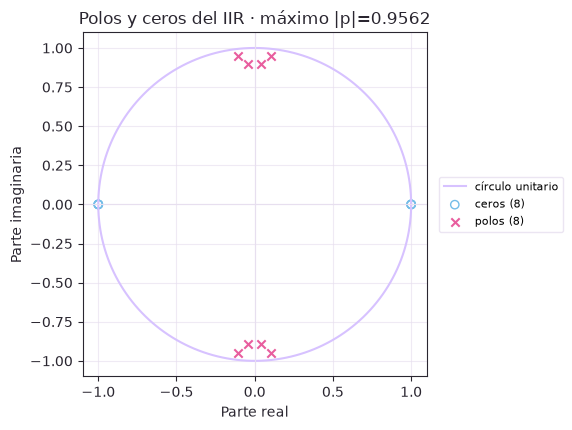

In [5]:
ang = np.linspace(0, 2 * np.pi, 400)

fig, ax = plt.subplots(figsize=(5.5, 4.4), constrained_layout=True)
ax.plot(np.cos(ang), np.sin(ang), color="#D7C2FF", label="círculo unitario")
ax.scatter(
    np.real(ceros_iir),
    np.imag(ceros_iir),
    marker="o",
    facecolors="none",
    edgecolors=COLOR_SERIE["fir"],
    label=f"ceros ({len(ceros_iir)})",
)
ax.scatter(
    np.real(polos_iir),
    np.imag(polos_iir),
    marker="x",
    color=COLOR_SERIE["iir"],
    label=f"polos ({len(polos_iir)})",
)
ax.axhline(0, color="#E7DFEF", linewidth=0.8)
ax.axvline(0, color="#E7DFEF", linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Polos y ceros del IIR · máximo |p|={radio_max_polo:.4f}")
ax.set_xlabel("Parte real")
ax.set_ylabel("Parte imaginaria")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
save_figure(fig, FIGURES_DIR / "nb04_polos_ceros_iir.png")
plt.show()


## Transformada Z aplicada al IIR

Para el filtro se puede escribir la función de transferencia como H(z) = sum(b_k z^(-k)) / sum(a_k z^(-k)). Los ceros anulan el numerador y los polos anulan el denominador. Al reemplazar z = exp(j omega) se obtiene la respuesta en frecuencia H(exp(j omega)).

Acá escribo H(z) con los coeficientes del diseño y comparo ese cálculo con scipy.signal.freqz. Si el error numérico es muy chico, las dos formas están describiendo el mismo filtro.

In [6]:
expresion_fir = transfer_function_expression(b_fir, a_fir)
expresion_iir = transfer_function_expression(b_iir, a_iir)

omega = np.linspace(0, np.pi, 2048)
h_z_iir = response_on_unit_circle(b_iir, a_iir, omega)
_, h_freqz_iir = signal.freqz(b_iir, a_iir, worN=omega)
error_h_z = np.max(np.abs(h_z_iir - h_freqz_iir))

print(expresion_fir)
print(expresion_iir)
print(f"Error máximo entre H(z) y freqz: {error_h_z:.2e}")

tabla_transformada_z = pd.DataFrame(
    [
        {
            "Filtro": "FIR",
            "Cantidad de ceros": len(zeros_and_poles(b_fir, a_fir)[0]),
            "Cantidad de polos": len(zeros_and_poles(b_fir, a_fir)[1]),
            "Radio máximo de polo": np.nan,
            "Error H(z) vs freqz": np.nan,
        },
        {
            "Filtro": "IIR",
            "Cantidad de ceros": len(ceros_iir),
            "Cantidad de polos": len(polos_iir),
            "Radio máximo de polo": radio_max_polo,
            "Error H(z) vs freqz": error_h_z,
        },
    ]
)
tabla_transformada_z.to_csv(TABLES_DIR / "nb04_transformada_z.csv", index=False)
display(tabla_transformada_z)

H(z) = [(-0.000242798) + (-7.64512e-05) z^(-1) + (0.000239382) z^(-2) + (7.26587e-05) z^(-3) + (-0.000223684) z^(-4) + (-6.51394e-05) z^(-5) + (0.000195753) z^(-6) + (5.40838e-05) z^(-7) + (-0.000155992) z^(-8) + (-3.9795e-05) z^(-9) + (0.000105226) z^(-10) + (2.27046e-05) z^(-11) + (-4.47738e-05) z^(-12) + (-3.38728e-06) z^(-13) + (-2.34734e-05) z^(-14) + (-1.74297e-05) z^(-15) + (9.70049e-05) z^(-16) + (3.88649e-05) z^(-17) + (-0.000172669) z^(-18) + (-5.98947e-05) z^(-19) + (0.000246705) z^(-20) + (7.938e-05) z^(-21) + (-0.000314831) z^(-22) + (-9.61099e-05) z^(-23) + (0.000372403) z^(-24) + (0.000108862) z^(-25) + (-0.000414641) z^(-26) + (-0.000116475) z^(-27) + (0.000436916) z^(-28) + (0.000117937) z^(-29) + (-0.000435094) z^(-30) + (-0.00011247) z^(-31) + (0.000405899) z^(-32) + (9.96226e-05) z^(-33) + (-0.000347291) z^(-34) + (-7.93409e-05) z^(-35) + (0.000258816) z^(-36) + (5.20321e-05) z^(-37) + (-0.00014189) z^(-38) + (-1.85971e-05) z^(-39) + (-1.95672e-05) z^(-41) + (0.0001

,Filtro,Cantidad de ceros,Cantidad de polos,Radio máximo de polo,Error H(z) vs freqz
0,FIR,400,0,NaN,NaN
1,IIR,8,8,0.956208,4.883031e-13


## Aplico los filtros

Como estoy trabajando offline con registros ya guardados, uso filtrado de fase cero (`filtfilt` / `sosfiltfilt`) para comparar el efecto del filtro sin sumar un corrimiento temporal extra.


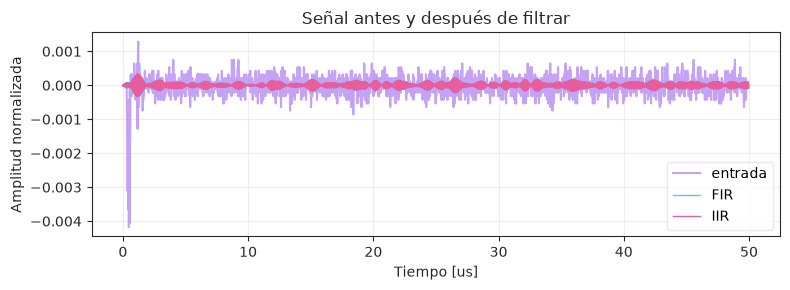

In [7]:
y_fir = signal.filtfilt(b_fir, a_fir, x_dron)
y_iir = signal.sosfiltfilt(sos_iir, x_dron)

n_tiempo = min(2_000, N)

fig, ax = plt.subplots()
ax.plot(tt_grafico[:n_tiempo], x_dron[:n_tiempo], label="entrada", alpha=0.75, color=COLOR_SERIE["antes"])
ax.plot(tt_grafico[:n_tiempo], y_fir[:n_tiempo], label="FIR", linewidth=1.0, color=COLOR_SERIE["fir"])
ax.plot(tt_grafico[:n_tiempo], y_iir[:n_tiempo], label="IIR", linewidth=1.0, color=COLOR_SERIE["iir"])
ax.set_title("Señal antes y después de filtrar")
ax.set_xlabel(f"Tiempo [{unidad_tiempo}]")
ax.set_ylabel("Amplitud normalizada")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb04_senal_filtrada.png")
plt.show()


## PSD antes y después

Por último comparo la PSD de la entrada contra la PSD después del FIR y del IIR. Si el filtro está haciendo lo esperado, la energía queda más concentrada dentro de la banda elegida.


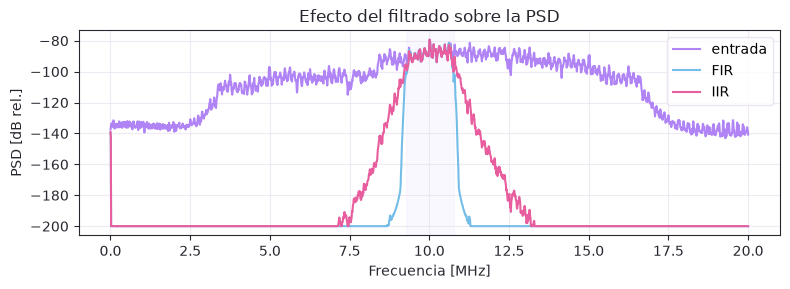

In [8]:
f_entrada, p_entrada = signal.welch(x_dron, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
f_fir_psd, p_fir = signal.welch(y_fir, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
f_iir_psd, p_iir = signal.welch(y_iir, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")

fig, ax = plt.subplots()
ax.plot(f_entrada / escala_f, 10 * np.log10(np.maximum(p_entrada, 1e-20)), label="entrada", color=COLOR_SERIE["antes"])
ax.plot(f_fir_psd / escala_f, 10 * np.log10(np.maximum(p_fir, 1e-20)), label="FIR", color=COLOR_SERIE["fir"])
ax.plot(f_iir_psd / escala_f, 10 * np.log10(np.maximum(p_iir, 1e-20)), label="IIR", color=COLOR_SERIE["iir"])
ax.axvspan(f1 / escala_f, f2 / escala_f, alpha=0.10, color="#D7C2FF")
ax.set_title("Efecto del filtrado sobre la PSD")
ax.set_xlabel(f"Frecuencia [{unidad_f}]")
ax.set_ylabel("PSD [dB rel.]")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb04_psd_filtrada.png")
plt.show()


In [9]:
def integrar_potencia(ff, psd, f_ini=None, f_fin=None):
    if f_ini is None:
        f_ini = ff[0]
    if f_fin is None:
        f_fin = ff[-1]

    idx = (ff >= f_ini) & (ff <= f_fin)
    if np.sum(idx) < 2:
        return 0.0

    return np.trapezoid(psd[idx], ff[idx])


def ganancia_db(freqs, respuesta, frecuencia):
    idx = int(np.argmin(np.abs(freqs - frecuencia)))
    return 20 * np.log10(max(abs(respuesta[idx]), 1e-12))

f_stop_baja = max(1.0, f1 - ancho_banda)
f_stop_alta = min(0.98 * fs / 2, f2 + ancho_banda)

tabla_respuesta = pd.DataFrame([
    {
        "filtro": "FIR",
        "orden_aproximado": len(b_fir) - 1,
        "estable": True,
        f"banda_inicio_{unidad_f}": f1 / escala_f,
        f"banda_fin_{unidad_f}": f2 / escala_f,
        "ganancia_centro_dB": ganancia_db(f_fir, h_fir, centro_banda),
        "ganancia_stop_baja_dB": ganancia_db(f_fir, h_fir, f_stop_baja),
        "ganancia_stop_alta_dB": ganancia_db(f_fir, h_fir, f_stop_alta),
        "radio_max_polo": 0.0,
    },
    {
        "filtro": "IIR Butterworth",
        "orden_aproximado": len(a_iir) - 1,
        "estable": estable_iir,
        f"banda_inicio_{unidad_f}": f1 / escala_f,
        f"banda_fin_{unidad_f}": f2 / escala_f,
        "ganancia_centro_dB": ganancia_db(f_iir, h_iir, centro_banda),
        "ganancia_stop_baja_dB": ganancia_db(f_iir, h_iir, f_stop_baja),
        "ganancia_stop_alta_dB": ganancia_db(f_iir, h_iir, f_stop_alta),
        "radio_max_polo": radio_max_polo,
    },
])

filas_potencia = []
for nombre, f_psd, psd in [
    ("entrada", f_entrada, p_entrada),
    ("FIR", f_fir_psd, p_fir),
    ("IIR", f_iir_psd, p_iir),
]:
    potencia_total = integrar_potencia(f_psd, psd)
    potencia_banda = integrar_potencia(f_psd, psd, f1, f2)
    filas_potencia.append({
        "senal": nombre,
        "potencia_total": potencia_total,
        "potencia_banda": potencia_banda,
        "proporcion_en_banda": potencia_banda / max(potencia_total, 1e-20),
    })

tabla_potencia = pd.DataFrame(filas_potencia)

tabla_respuesta.to_csv(TABLES_DIR / "nb04_filtros.csv", index=False)
tabla_potencia.to_csv(TABLES_DIR / "nb04_potencia_filtrado.csv", index=False)

display(tabla_respuesta.round(4))
display(tabla_potencia.round(4))


,filtro,orden_aproximado,estable,banda_inicio_MHz,banda_fin_MHz,ganancia_centro_dB,ganancia_stop_baja_dB,ganancia_stop_alta_dB,radio_max_polo
0,FIR,400,True,9.2598,10.7598,-0.0,-61.5781,-63.2465,0.0000
1,IIR Butterworth,8,True,9.2598,10.7598,-0.0,-39.5066,-39.5247,0.9562


,senal,potencia_total,potencia_banda,proporcion_en_banda
0,entrada,0.0086,0.0030,0.3438
1,FIR,0.0028,0.0028,0.9983
2,IIR,0.0027,0.0026,0.9765
